## BERT 모델 전이학습

데이터셋 정의

In [ ]:
import torch
from transformers import BertTokenizer, BertForMaskedLM
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from tqdm import tqdm

class MaskedDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128, mask_probability=0.15):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.mask_probability = mask_probability

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )  # Tokenize input text
        input_ids = encoding["input_ids"].squeeze(0)            # ex) text="Hello world" → input_ids=[101, 7592, 2088, 102, 0, 0, ...] (padded to max_length)
        padding_mask = encoding["attention_mask"].squeeze(0)    # ex) text="Hello world" → attention_mask=[1, 1, 1, 1, 0, 0, ...] (1 for real tokens, 0 for padding)

        # Create masked input and labels
        labels = input_ids.clone() # tokenize labels for loss calculation
        rand = torch.rand(input_ids.shape)
        mask_arr = (rand < self.mask_probability) * (input_ids != self.tokenizer.cls_token_id) * (input_ids != self.tokenizer.sep_token_id) * (input_ids != self.tokenizer.pad_token_id) # Create a boolean mask to determine which tokens can be masked, excluding special tokens ([CLS], [SEP], [PAD])

        # Random mask condition
        mask_condition = rand < self.mask_probability   # if mask_probability=0.15 → True for ~15% positions (rand=[0.1,0.7] → [True, False])

        # Exclude special tokens
        not_cls = input_ids != self.tokenizer.cls_token_id  # [CLS]=101 → input_ids=[101, 200, 300] → [False, True, True]
        not_sep = input_ids != self.tokenizer.sep_token_id  # [SEP]=102 → input_ids=[200,102,300] → [True, False, True]
        not_pad = input_ids != self.tokenizer.pad_token_id  # [PAD]=0 → input_ids=[200,0,300] → [True, False, True]

        # Combine all conditions
        mask_arr = mask_condition & not_cls & not_sep & not_pad # [True, True, False] & [True, False, True] → [True, False, False]

        input_ids[mask_arr] = self.tokenizer.mask_token_id  # Replace with [MASK]

        return {
            "input_ids": input_ids, # Masked tokenized input text
            "attention_mask": padding_mask,  # Attention mask for the input
            "labels": labels # Original tokenized input text (used as labels for loss calculation)
        }


토크나이저 및 데이터 준비

- tokenizer.cls_token   # "[CLS]". 문장시작
- tokenizer.sep_token   # "[SEP]". 문장끝
- tokenizer.pad_token   # "[PAD]". 패밍
- tokenizer.mask_token  # "[MASK]". 마스킹 (MLM 학습용)
- tokenizer.unk_token   # "[UNK]". 미정토큰

In [ ]:
texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is transforming the world.",
    "BERT stands for Bidirectional Encoder Representations from Transformers."
]

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased") # https://huggingface.co/bert-base-uncased
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")
print(f'CLS token ID: {tokenizer.cls_token_id}, SEP token ID: {tokenizer.sep_token_id}, PAD token ID: {tokenizer.pad_token_id}, MASK token ID: {tokenizer.mask_token_id}, Unknown token ID: {tokenizer.unk_token_id}')

dataset = MaskedDataset(texts, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

Tokenizer vocab size: 30522
CLS token ID: 101, SEP token ID: 102, PAD token ID: 0, MASK token ID: 103, Unknown token ID: 100


모델 및 옵티마이저 초기화

In [ ]:
model = BertForMaskedLM.from_pretrained("bert-base-uncased") # https://huggingface.co/bert-base-uncased
optimizer = AdamW(model.parameters(), lr=5e-5)


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


모델 학습

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

losses = []
epochs = 500
for epoch in range(epochs):
    model.train()

    for batch in dataloader:
        # Move data to device
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels) # ouputs.loss = CE(logits[BATCH_SIZE, :-1, VOCAB_SIZE], labels[BATCH_SIZE, 1:, VOCAB_SIZE]). refer to https://huggingface.co/docs/transformers/main_classes/output
        loss = outputs.loss
        losses.append(loss.item())
        if (epoch + 1) % 50 == 0: # Print loss every 50 epochs
            print(f"Epoch {epoch + 1} Loss: {loss.item():.4f}")

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Epoch 50 Loss: 0.0255
Epoch 50 Loss: 0.0202
Epoch 100 Loss: 0.0084
Epoch 100 Loss: 0.0083
Epoch 150 Loss: 0.0105
Epoch 150 Loss: 0.0048
Epoch 200 Loss: 0.0092
Epoch 200 Loss: 0.0033
Epoch 250 Loss: 0.0743
Epoch 250 Loss: 0.0021
Epoch 300 Loss: 0.0019
Epoch 300 Loss: 0.0025
Epoch 350 Loss: 0.0012
Epoch 350 Loss: 0.0012
Epoch 400 Loss: 0.0012
Epoch 400 Loss: 0.0010
Epoch 450 Loss: 0.0008
Epoch 450 Loss: 0.0009
Epoch 500 Loss: 0.0007
Epoch 500 Loss: 0.0011


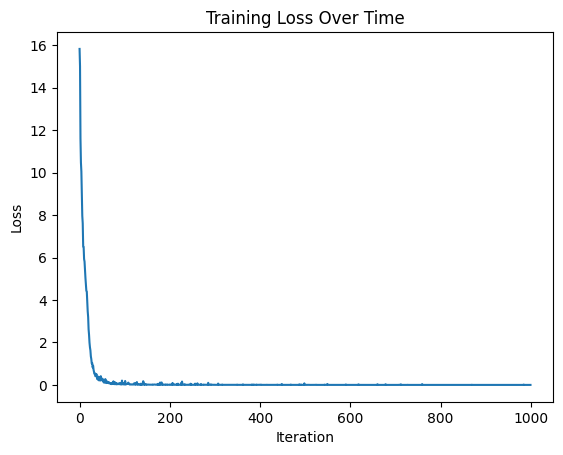

In [13]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()

테스트 문자열 준비

In [14]:
test_texts = [
    "The quick brown [MASK] jumps over the lazy dog.",
    "Artificial intelligence is [MASK] the world.",
    "BERT stands for [MASK] Encoder Representations from Transformers."
]

# 토크나이저로 테스트 데이터 인코딩
test_encodings = tokenizer(
    test_texts,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

# 토큰 시퀀스와 어텐션 마스크를 디바이스로 이동
input_ids = test_encodings["input_ids"].to(device)
attention_mask = test_encodings["attention_mask"].to(device)


모델 평가

In [15]:
model.eval()

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    predictions = outputs.logits

평가 결과 출력

In [ ]:
for i, test_text in enumerate(test_texts):
    mask_positions = input_ids[i] == tokenizer.mask_token_id    # [101, 200, 103, 300] → [False, False, True, False]
    mask_indices = mask_positions.nonzero(as_tuple=True)        # (tensor([2]),)
    mask_indices = mask_indices[0]      # tensor([2])
    masked_index = mask_indices.item()  # 2

    # mask 된 토큰의 예측된 단어 사전 중 가장 높은 확률을 가진 토큰 ID 추출
    logits = predictions[i, masked_index]               # shape: [vocab_size]. vocab_size=30522 (BERT)
    predicted_token_id_tensor = logits.argmax(dim=-1)   # ex) logits=[0.1, 0.2, 0.05, ..., 0.3] → predicted_token_id_tensor=7592
    predicted_token_id = predicted_token_id_tensor.item()   # 7592
    print(f"logits shape: {logits.shape}, logit: {logits[predicted_token_id]}, predicted_token_id: {predicted_token_id}")
    predicted_token = tokenizer.decode([predicted_token_id])                # 예측된 토큰 ID를 실제 단어로 디코딩

    print(f"Original: {test_text}")
    print(f"Prediction: {test_text.replace(tokenizer.mask_token, predicted_token)}") # [MASK] 토큰을 예측된 단어로 대체하여 출력


logits shape: torch.Size([30522]), logit: 17.659955978393555, predicted_token_id: 4419
Original: The quick brown [MASK] jumps over the lazy dog.
Prediction: The quick brown fox jumps over the lazy dog.
logits shape: torch.Size([30522]), logit: 19.525054931640625, predicted_token_id: 17903
Original: Artificial intelligence is [MASK] the world.
Prediction: Artificial intelligence is transforming the world.
logits shape: torch.Size([30522]), logit: 9.190582275390625, predicted_token_id: 7226
Original: BERT stands for [MASK] Encoder Representations from Transformers.
Prediction: BERT stands for bid Encoder Representations from Transformers.
